In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
import pingouin as pg
from sklearn import tree


In [18]:
baseball_df_HOF = pd.read_csv('baseball_df_HOF.csv')
baseball_df_active = pd.read_csv('baseball_df_active.csv')
baseball_df_HOF.head()

,HOF_status,PA,HR,R,RBI,AVG,OBP,SLG,wRC+,Off,WAR
0,1,10616,714,2174,2217,0.342,0.474,0.690,194,1336.3,167.0
1,1,12541,660,2068,1909,0.301,0.384,0.557,154,835.8,149.8
2,1,13072,117,2246,1937,0.366,0.433,0.512,164,1027.9,149.1
3,1,11739,101,1736,1732,0.327,0.391,0.466,147,704.7,138.1
4,1,13940,755,2174,2297,0.305,0.374,0.555,153,882.0,136.3


In [10]:
# perform logistic regression on our data
X = baseball_df_HOF.drop('HOF_status', axis = 1)
y = baseball_df_HOF['HOF_status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

# Standardize as we have different scales for each variable
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

# Oversample the data as it is imbalanced
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)



#from imblearn.under_sampling import ClusterCentroids

#rus = ClusterCentroids(random_state=42)
#X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
# Undersampling gives us a lower recall than oversampling

regression = LogisticRegression(random_state=42).fit(X_resampled, y_resampled)
y_predicted = regression.predict(X_test)

regression.score(X_test, y_test)


0.8941176470588236

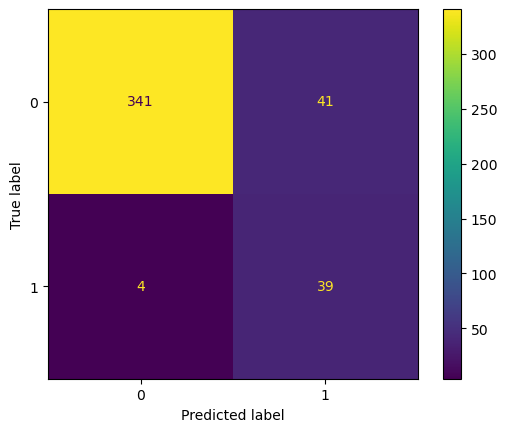

In [11]:
# Check our results
ConfusionMatrixDisplay.from_estimator(regression, X_test, y_test)

In [12]:
def recall(tp, fn):
    return tp / (tp + fn)
recall(39, 4)


0.9069767441860465

In [13]:
# decision tree

model = tree.DecisionTreeClassifier(max_depth=7, random_state=50)

In [14]:
decision_tree = model.fit(X_resampled, y_resampled)
y_pred = decision_tree.predict(X_test)

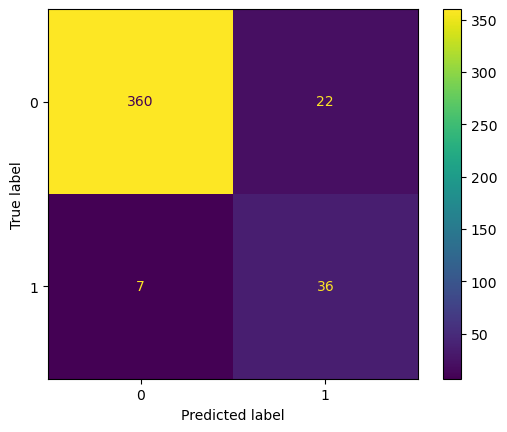

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [16]:
recall(36,7)

0.8372093023255814

In [19]:
# now we want to apply our logistic regression model to the active players to see who we predict will be in the HOF
# we will use the logistic regression as it had a higher recall than the decision tree
active_names = baseball_df_active['Name']


In [20]:
# drop the same columns as before plus name and HOF_status
active_X = baseball_df_active.drop(columns=['Name', 'HOF_status', 'Def', 'SB', 'G'])

In [21]:
# scale our data
active_X_scaled = sc.transform(active_X)


In [22]:
# predict HOF status and probability of a player being a HOFer (probability of HOF_status being 1)
active_predictions = regression.predict(active_X_scaled)
active_probabilities = regression.predict_proba(active_X_scaled)[:, 1]

In [23]:
# results data frame
active_results = pd.DataFrame({
    'Name': active_names.values,
    'HOF_Prediction': active_predictions,
    'HOF_Probability': active_probabilities
})

In [24]:
active_results_sorted = active_results.sort_values('HOF_Probability', ascending=False)
print(active_results_sorted)

               Name  HOF_Prediction  HOF_Probability
0        Mike Trout               1         0.972895
1   Freddie Freeman               1         0.937093
5       Jose Altuve               1         0.860928
11    Nolan Arenado               1         0.832708
8     Manny Machado               1         0.813072
..              ...             ...              ...
35        Max Muncy               0         0.001595
44     Joc Pederson               0         0.001031
57   Kyle Schwarber               0         0.001024
50     Rhys Hoskins               0         0.000639
52      Jorge Soler               0         0.000493

[66 rows x 3 columns]


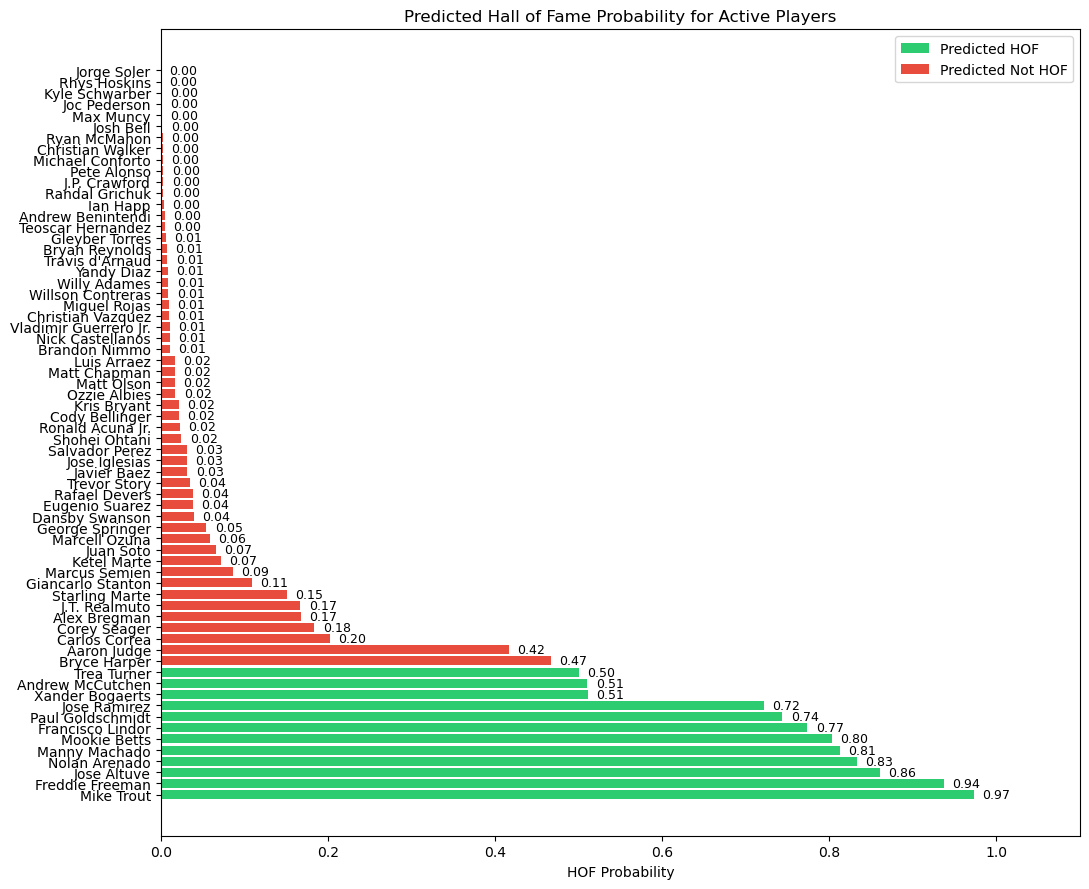

In [25]:
# Plot HOF probability for active players
fig, ax = plt.subplots(figsize=(11, 9))

# Color bars by prediction (HOF vs not)
colors = ['#2ecc71' if p == 1 else '#e74c3c' for p in active_results_sorted['HOF_Prediction']]

bars = ax.barh(active_results_sorted['Name'], active_results_sorted['HOF_Probability'], color=colors)


# Label each bar with its probability
for bar, prob in zip(bars, active_results_sorted['HOF_Probability']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{prob:.2f}', va='center', fontsize=9)

ax.set_xlabel('HOF Probability')
ax.set_title('Predicted Hall of Fame Probability for Active Players')
ax.set_xlim(0, 1.1)  # extra space for labels on the right

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Predicted HOF'),
                   Patch(facecolor='#e74c3c', label='Predicted Not HOF')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()